## Imports and Setup

This notebook performs Multivariate Singular Spectrum Analysis (mSSA) on cleaned commodity return series to identify shared latent factors across commodity markets.

We use the cleaned log-return dataset generated during preprocessing and analyze common structure across energy, agriculture, metals, and other commodity sectors.

In [1]:
# Standard library
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Linear algebra / decomposition
from numpy.linalg import svd

# Notebook display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Plot styling
sns.set_theme(style="whitegrid")

# File paths
RETURNS_PATH = Path("data/commodity_returns_cleaned.csv")
PRICES_PATH = Path("data/commodity_prices_cleaned.csv")

In [2]:
# Load cleaned commodity returns
returns_df = pd.read_csv(
    "../data/commodity_returns_cleaned.csv",
    parse_dates=["Date"],
    index_col="Date"
)

# Quick inspection
print(f"Shape: {returns_df.shape}")

returns_df.head()

Shape: (6091, 22)


,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,LIVE CATTLE,SOYBEAN OIL,ALUMINIUM,SOYBEAN MEAL,ZINC,ULS DIESEL,NICKEL,WHEAT,SUGAR,COFFEE,LEAN HOGS,HRW WHEAT,COTTON
Date,,,,,,,,,,,,,,,,,,,,,,
2000-01-04,0.000000,0.000000,0.000000,0.000000,0.016835,0.011146,0.000000,0.000000,0.000000,-0.009007,0.008384,0.000000,0.010194,-0.018349,0.000000,-0.015752,-0.001011,-0.055617,-0.002148,-0.006272,-0.000912,-0.006680
2000-01-05,-0.003683,-0.005656,-0.025368,-0.027433,0.010712,0.000000,0.009974,-0.031179,-0.002345,-0.001449,0.010859,0.011678,0.018755,-0.004744,-0.018314,-0.000842,0.010060,0.006908,0.020013,-0.009937,0.008178,0.016229
2000-01-06,0.012832,0.001063,-0.005232,-0.004646,-0.002667,0.003688,-0.004095,-0.008288,-0.008250,0.015822,-0.001271,0.001984,-0.010674,0.002272,-0.004065,-0.006643,-0.005018,-0.006908,-0.014865,0.001814,-0.004535,0.010035
2000-01-07,-0.010529,0.001769,-0.022858,-0.022694,0.007451,0.015825,0.001172,0.005404,-0.028814,0.011352,0.011385,0.007443,0.000000,-0.002272,-0.023354,-0.009497,0.012994,0.012059,-0.023378,0.008123,0.009950,0.035462
2000-01-10,0.019595,-0.000707,0.018409,0.027340,-0.011197,0.007220,-0.008821,-0.000963,-0.046114,-0.001412,-0.012022,-0.009274,-0.009434,-0.010391,-0.000463,-0.005397,0.006927,-0.001714,0.029350,0.000449,0.007175,-0.007441


## Inspect Data Structure

We inspect the dataset structure, verify chronological ordering, review the commodity series included in the analysis, and check for missing values before applying mSSA.

In [3]:
# Basic dataset inspection
print("Dataset shape:", returns_df.shape)

print("\nDate range:")
print("Start:", returns_df.index.min())
print("End:", returns_df.index.max())

print("\nChronologically sorted:")
print(returns_df.index.is_monotonic_increasing)

print("\nCommodity series:")
print(list(returns_df.columns))

print("\nMissing values:")
display(returns_df.isna().sum()[returns_df.isna().sum() > 0])

# Preview data
display(returns_df.head())
display(returns_df.tail())

Dataset shape: (6091, 22)

Date range:
Start: 2000-01-04 00:00:00
End: 2023-08-04 00:00:00

Chronologically sorted:
True

Commodity series:
['NATURAL GAS', 'GOLD', 'WTI CRUDE', 'BRENT CRUDE', 'SOYBEANS', 'CORN', 'COPPER', 'SILVER', 'LOW SULPHUR GAS OIL', 'LIVE CATTLE', 'SOYBEAN OIL', 'ALUMINIUM', 'SOYBEAN MEAL', 'ZINC', 'ULS DIESEL', 'NICKEL', 'WHEAT', 'SUGAR', 'COFFEE', 'LEAN HOGS', 'HRW WHEAT', 'COTTON']

Missing values:


Series([], dtype: int64)

,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,LIVE CATTLE,SOYBEAN OIL,ALUMINIUM,SOYBEAN MEAL,ZINC,ULS DIESEL,NICKEL,WHEAT,SUGAR,COFFEE,LEAN HOGS,HRW WHEAT,COTTON
Date,,,,,,,,,,,,,,,,,,,,,,
2000-01-04,0.000000,0.000000,0.000000,0.000000,0.016835,0.011146,0.000000,0.000000,0.000000,-0.009007,0.008384,0.000000,0.010194,-0.018349,0.000000,-0.015752,-0.001011,-0.055617,-0.002148,-0.006272,-0.000912,-0.006680
2000-01-05,-0.003683,-0.005656,-0.025368,-0.027433,0.010712,0.000000,0.009974,-0.031179,-0.002345,-0.001449,0.010859,0.011678,0.018755,-0.004744,-0.018314,-0.000842,0.010060,0.006908,0.020013,-0.009937,0.008178,0.016229
2000-01-06,0.012832,0.001063,-0.005232,-0.004646,-0.002667,0.003688,-0.004095,-0.008288,-0.008250,0.015822,-0.001271,0.001984,-0.010674,0.002272,-0.004065,-0.006643,-0.005018,-0.006908,-0.014865,0.001814,-0.004535,0.010035
2000-01-07,-0.010529,0.001769,-0.022858,-0.022694,0.007451,0.015825,0.001172,0.005404,-0.028814,0.011352,0.011385,0.007443,0.000000,-0.002272,-0.023354,-0.009497,0.012994,0.012059,-0.023378,0.008123,0.009950,0.035462
2000-01-10,0.019595,-0.000707,0.018409,0.027340,-0.011197,0.007220,-0.008821,-0.000963,-0.046114,-0.001412,-0.012022,-0.009274,-0.009434,-0.010391,-0.000463,-0.005397,0.006927,-0.001714,0.029350,0.000449,0.007175,-0.007441


,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,LIVE CATTLE,SOYBEAN OIL,ALUMINIUM,SOYBEAN MEAL,ZINC,ULS DIESEL,NICKEL,WHEAT,SUGAR,COFFEE,LEAN HOGS,HRW WHEAT,COTTON
Date,,,,,,,,,,,,,,,,,,,,,,
2023-07-31,0.008005,0.005343,0.022751,0.016736,-0.041327,-0.047939,0.023988,0.020103,-0.001708,-0.003364,-0.061503,0.037361,-0.008606,0.044051,0.008023,0.027862,-0.054443,0.004990,0.044079,0.011834,-0.050093,-0.001520
2023-08-01,-0.028496,-0.015239,-0.005271,-0.007626,0.000691,-0.013986,-0.025139,-0.026209,0.038300,0.008111,0.022764,-0.015835,0.010801,0.001356,0.010808,0.002798,-0.020486,0.011547,-0.000608,-0.004331,-0.010203,0.016598
2023-08-02,-0.032959,-0.001702,-0.023375,-0.020345,-0.011820,-0.017762,-0.016770,-0.018840,-0.030069,-0.008251,0.003274,-0.023253,-0.009472,-0.034896,-0.006337,-0.037188,-0.018960,-0.007821,0.014480,-0.009692,-0.021993,-0.020821
2023-08-03,0.034910,-0.002791,0.025585,0.023050,-0.000700,-0.015480,0.014465,-0.007358,0.016817,0.002665,-0.004765,0.008256,-0.001329,0.003012,0.023228,0.001075,-0.020522,-0.007466,-0.013265,-0.016448,-0.025090,0.002348
2023-08-04,0.006218,0.003617,0.009641,0.008887,0.008537,0.003634,-0.009922,-0.000929,0.004160,0.009201,0.014670,0.000000,-0.013836,0.000000,-0.004106,0.000000,0.007943,-0.010042,-0.013444,-0.002975,-0.009491,0.002342


## Train / Validation / Test Split

We split the dataset chronologically to avoid look-ahead bias:

- Training: 70%
- Validation: 15%
- Test: 15%

In [4]:
# Compute split indices
n = len(returns_df)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

# Chronological splits
train_df = returns_df.iloc[:train_end]
val_df = returns_df.iloc[train_end:val_end]
test_df = returns_df.iloc[val_end:]

# Verify split sizes
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

# Verify date ranges
print("\nTrain period:")
print(train_df.index.min(), "to", train_df.index.max())

print("\nValidation period:")
print(val_df.index.min(), "to", val_df.index.max())

print("\nTest period:")
print(test_df.index.min(), "to", test_df.index.max())

Train shape: (4263, 22)
Validation shape: (914, 22)
Test shape: (914, 22)

Train period:
2000-01-04 00:00:00 to 2016-07-12 00:00:00

Validation period:
2016-07-13 00:00:00 to 2020-01-27 00:00:00

Test period:
2020-01-28 00:00:00 to 2023-08-04 00:00:00


## Standardization

We standardize each commodity return series using the training-set mean and standard deviation. The same transformation is then applied to the validation and test sets to prevent data leakage.

In [5]:
# Compute training statistics
train_mean = train_df.mean()
train_std = train_df.std()

# Standardize datasets
train_scaled = (train_df - train_mean) / train_std
val_scaled = (val_df - train_mean) / train_std
test_scaled = (test_df - train_mean) / train_std

# Validate scaling
print("Training means (approx. 0):")
display(train_scaled.mean().round(3))

print("\nTraining standard deviations (approx. 1):")
display(train_scaled.std().round(3))

Training means (approx. 0):


NATURAL GAS            0.0
GOLD                  -0.0
WTI CRUDE             -0.0
BRENT CRUDE           -0.0
SOYBEANS              -0.0
CORN                   0.0
COPPER                -0.0
SILVER                 0.0
LOW SULPHUR GAS OIL   -0.0
LIVE CATTLE            0.0
SOYBEAN OIL            0.0
ALUMINIUM             -0.0
SOYBEAN MEAL          -0.0
ZINC                  -0.0
ULS DIESEL             0.0
NICKEL                 0.0
WHEAT                  0.0
SUGAR                  0.0
COFFEE                 0.0
LEAN HOGS             -0.0
HRW WHEAT             -0.0
COTTON                 0.0
dtype: float64


Training standard deviations (approx. 1):


NATURAL GAS            1.0
GOLD                   1.0
WTI CRUDE              1.0
BRENT CRUDE            1.0
SOYBEANS               1.0
CORN                   1.0
COPPER                 1.0
SILVER                 1.0
LOW SULPHUR GAS OIL    1.0
LIVE CATTLE            1.0
SOYBEAN OIL            1.0
ALUMINIUM              1.0
SOYBEAN MEAL           1.0
ZINC                   1.0
ULS DIESEL             1.0
NICKEL                 1.0
WHEAT                  1.0
SUGAR                  1.0
COFFEE                 1.0
LEAN HOGS              1.0
HRW WHEAT              1.0
COTTON                 1.0
dtype: float64

## Select mSSA Input Panel

We use the standardized training returns as the input panel for mSSA. This keeps the analysis focused on shared co-movement patterns rather than differences in volatility across commodities.

In [6]:
# Select the commodity panel for mSSA
# Start with all available commodity return series
mssa_panel = train_scaled.copy()

# Optional: drop any columns with remaining missing or infinite values
mssa_panel = mssa_panel.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

print("mSSA panel shape:", mssa_panel.shape)
print("Commodities included:")
print(list(mssa_panel.columns))

mSSA panel shape: (4263, 22)
Commodities included:
['NATURAL GAS', 'GOLD', 'WTI CRUDE', 'BRENT CRUDE', 'SOYBEANS', 'CORN', 'COPPER', 'SILVER', 'LOW SULPHUR GAS OIL', 'LIVE CATTLE', 'SOYBEAN OIL', 'ALUMINIUM', 'SOYBEAN MEAL', 'ZINC', 'ULS DIESEL', 'NICKEL', 'WHEAT', 'SUGAR', 'COFFEE', 'LEAN HOGS', 'HRW WHEAT', 'COTTON']


## Choose Embedding Window Length

mSSA uses lagged versions of each commodity series to capture temporal structure. The window length controls how much history is included in each lagged vector.

Here, we choose a moderate window length that is long enough to capture medium-term co-movement patterns but short enough to preserve enough observations for decomposition.

In [7]:
# Choose embedding window length
# For daily data, this uses roughly one trading month of history.
L = 30

n_obs, n_series = mssa_panel.shape
K = n_obs - L + 1

print("Number of observations:", n_obs)
print("Number of commodity series:", n_series)
print("Window length L:", L)
print("Number of lagged windows K:", K)

if K <= 0:
    raise ValueError("Window length L is too large for the number of observations.")

Number of observations: 4263
Number of commodity series: 22
Window length L: 30
Number of lagged windows K: 4234


## Build Multivariate Trajectory Matrix

We construct the mSSA trajectory matrix by stacking lagged windows from each commodity series. Each commodity contributes a lagged trajectory block, and the blocks are combined into one multivariate matrix for singular value decomposition.

In [8]:
def build_trajectory_matrix(panel: pd.DataFrame, window_length: int) -> np.ndarray:
    """
    Build a multivariate SSA trajectory matrix.

    Rows: lagged values for each commodity across the window length
    Columns: rolling time windows
    """
    X = panel.to_numpy()
    n_obs, n_series = X.shape
    K = n_obs - window_length + 1

    trajectory_blocks = []

    for j in range(n_series):
        series = X[:, j]
        block = np.column_stack([
            series[i:i + K] for i in range(window_length)
        ]).T
        trajectory_blocks.append(block)

    trajectory_matrix = np.vstack(trajectory_blocks)

    return trajectory_matrix


X_traj = build_trajectory_matrix(mssa_panel, L)

print("Trajectory matrix shape:", X_traj.shape)
print("Expected rows:", L * n_series)
print("Expected columns:", K)

Trajectory matrix shape: (660, 4234)
Expected rows: 660
Expected columns: 4234


## Run SVD

We apply singular value decomposition (SVD) to the multivariate trajectory matrix. The singular values measure the strength of each extracted mSSA component, with larger singular values representing more dominant shared patterns across commodities.

In [9]:
# Run singular value decomposition
U, singular_values, Vt = svd(X_traj, full_matrices=False)

print("U shape:", U.shape)
print("Singular values shape:", singular_values.shape)
print("Vt shape:", Vt.shape)

# Preview leading singular values
pd.DataFrame({
    "component": np.arange(1, len(singular_values) + 1),
    "singular_value": singular_values
}).head(10)

U shape: (660, 660)
Singular values shape: (660,)
Vt shape: (660, 4234)


,component,singular_value
0,1,180.124955
1,2,172.135888
2,3,171.796634
3,4,167.547147
4,5,166.489539
5,6,165.924052
6,7,163.697220
7,8,163.618373
8,9,162.931219
9,10,162.452236


## Calculate Variance Explained

The variance explained by each component is calculated using the squared singular values. This tells us how much of the total variation in the trajectory matrix is captured by each mSSA component.

In [10]:
# Calculate variance explained
eigenvalues = singular_values ** 2

variance_explained = eigenvalues / eigenvalues.sum()
cumulative_variance_explained = np.cumsum(variance_explained)

variance_df = pd.DataFrame({
    "component": np.arange(1, len(singular_values) + 1),
    "singular_value": singular_values,
    "variance_explained": variance_explained,
    "cumulative_variance_explained": cumulative_variance_explained
})

# Display leading components
variance_df.head(15)

,component,singular_value,variance_explained,cumulative_variance_explained
0,1,180.124955,0.011610,0.011610
1,2,172.135888,0.010603,0.022213
2,3,171.796634,0.010561,0.032774
3,4,167.547147,0.010045,0.042819
4,5,166.489539,0.009919,0.052737
5,6,165.924052,0.009851,0.062589
6,7,163.697220,0.009589,0.072177
7,8,163.618373,0.009579,0.081757
8,9,162.931219,0.009499,0.091256
9,10,162.452236,0.009443,0.100699


## Scree Plot

The scree plot shows how quickly component importance declines. A steep drop after the first few components suggests that a small number of shared latent factors explain much of the commodity co-movement.

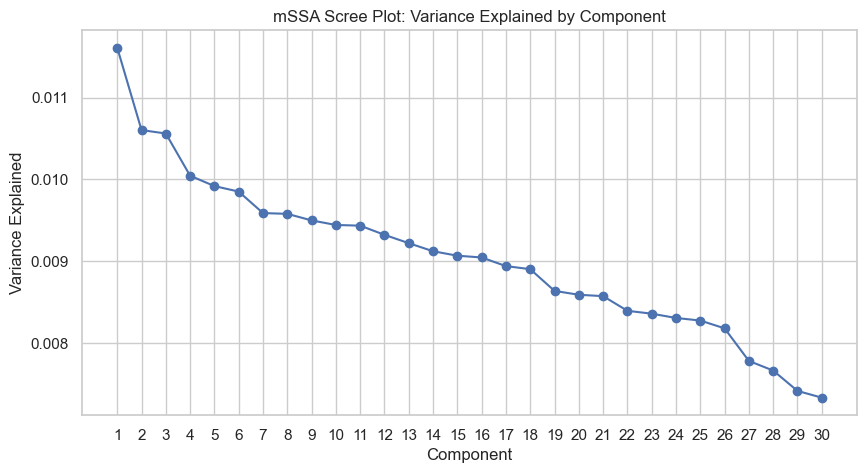

In [11]:
# Plot scree plot using variance explained
n_components_to_plot = min(30, len(variance_df))

plt.figure(figsize=(10, 5))
plt.plot(
    variance_df["component"].iloc[:n_components_to_plot],
    variance_df["variance_explained"].iloc[:n_components_to_plot],
    marker="o"
)

plt.title("mSSA Scree Plot: Variance Explained by Component")
plt.xlabel("Component")
plt.ylabel("Variance Explained")
plt.xticks(range(1, n_components_to_plot + 1))
plt.grid(True)
plt.show()

## Extract Leading Components

Because the singular value spectrum is relatively flat, we select only a small number of leading components for interpretation. These components represent the strongest shared patterns detected by mSSA, even if each explains a modest share of total variance.

In [12]:
# Number of leading components to interpret
n_leading = 5

leading_components = list(range(n_leading))

print("Leading components selected:", [i + 1 for i in leading_components])

display(
    variance_df.loc[leading_components, [
        "component",
        "singular_value",
        "variance_explained",
        "cumulative_variance_explained"
    ]]
)

Leading components selected: [1, 2, 3, 4, 5]


,component,singular_value,variance_explained,cumulative_variance_explained
0,1,180.124955,0.011610,0.011610
1,2,172.135888,0.010603,0.022213
2,3,171.796634,0.010561,0.032774
3,4,167.547147,0.010045,0.042819
4,5,166.489539,0.009919,0.052737


## Reconstruct Leading Components Over Time

Each mSSA component is first reconstructed in trajectory-matrix form using one singular triplet. We then convert each reconstructed trajectory matrix back into a time series using diagonal averaging.

For interpretation, we summarize each reconstructed component across commodities to obtain one representative latent factor time series per component.

In [13]:
def diagonal_average(block: np.ndarray) -> np.ndarray:
    """
    Convert one reconstructed SSA trajectory block back into a time series
    using diagonal averaging.
    
    block shape: (L, K)
    output length: L + K - 1
    """
    L_block, K_block = block.shape
    n_reconstructed = L_block + K_block - 1
    
    reconstructed = np.zeros(n_reconstructed)
    counts = np.zeros(n_reconstructed)
    
    for i in range(L_block):
        for j in range(K_block):
            reconstructed[i + j] += block[i, j]
            counts[i + j] += 1
            
    return reconstructed / counts


def reconstruct_mssa_component(component_idx: int, U: np.ndarray, singular_values: np.ndarray, Vt: np.ndarray,
                               window_length: int, n_series: int, columns: list, index: pd.Index) -> pd.DataFrame:
    """
    Reconstruct one mSSA component for each commodity series.
    """
    # Reconstruct rank-one trajectory matrix for selected component
    X_component = singular_values[component_idx] * np.outer(U[:, component_idx], Vt[component_idx, :])
    
    reconstructed_series = {}
    
    for j, col in enumerate(columns):
        row_start = j * window_length
        row_end = (j + 1) * window_length
        
        block_j = X_component[row_start:row_end, :]
        reconstructed_series[col] = diagonal_average(block_j)
        
    reconstructed_df = pd.DataFrame(reconstructed_series, index=index)
    
    return reconstructed_df


# Reconstruct selected leading components
reconstructed_components = {}

for component_idx in leading_components:
    reconstructed_components[component_idx + 1] = reconstruct_mssa_component(
        component_idx=component_idx,
        U=U,
        singular_values=singular_values,
        Vt=Vt,
        window_length=L,
        n_series=n_series,
        columns=list(mssa_panel.columns),
        index=mssa_panel.index
    )

print("Reconstructed components:")
print(list(reconstructed_components.keys()))

# Example: preview reconstructed commodity-level series for component 1
reconstructed_components[1].head()

Reconstructed components:
[1, 2, 3, 4, 5]


,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,LIVE CATTLE,SOYBEAN OIL,ALUMINIUM,SOYBEAN MEAL,ZINC,ULS DIESEL,NICKEL,WHEAT,SUGAR,COFFEE,LEAN HOGS,HRW WHEAT,COTTON
Date,,,,,,,,,,,,,,,,,,,,,,
2000-01-04,-0.035989,-0.028865,-0.053620,-0.062764,-0.063753,-0.059033,-0.084873,-0.051302,-0.038972,-0.014479,-0.057603,-0.069710,-0.047217,-0.064008,-0.048013,-0.060480,-0.057283,-0.035824,-0.026442,-0.013299,-0.056784,-0.018364
2000-01-05,0.039733,0.032692,0.059610,0.069342,0.073099,0.066342,0.093708,0.056173,0.036719,0.015008,0.066161,0.076551,0.053857,0.069161,0.052128,0.065328,0.064929,0.039090,0.028468,0.014053,0.064751,0.022179
2000-01-06,-0.043527,-0.033484,-0.064393,-0.075475,-0.078944,-0.071254,-0.099959,-0.058539,-0.038178,-0.014781,-0.071701,-0.081397,-0.057843,-0.072673,-0.056290,-0.069502,-0.069707,-0.041382,-0.029195,-0.014139,-0.069450,-0.023303
2000-01-07,0.046809,0.036265,0.070512,0.082575,0.084928,0.076486,0.107069,0.062991,0.041500,0.015773,0.078222,0.086813,0.061940,0.077886,0.061464,0.075399,0.075136,0.044023,0.030335,0.014852,0.075019,0.025412
2000-01-10,-0.048204,-0.038508,-0.074555,-0.087153,-0.088493,-0.078843,-0.111140,-0.065395,-0.043306,-0.016422,-0.082711,-0.090311,-0.064376,-0.081823,-0.064874,-0.079390,-0.078315,-0.045559,-0.031098,-0.015208,-0.078133,-0.027467


## Plot Reconstructed Leading Components

To visualize the dominant shared factors, we average the reconstructed commodity-level series within each component. This creates one representative time series for each leading mSSA component.

,Component 1,Component 2,Component 3,Component 4,Component 5
Date,,,,,
2000-01-04,-0.047667,0.078470,-0.018690,0.048659,-0.075359
2000-01-05,0.052685,-0.068244,-0.109079,-0.007962,-0.054027
2000-01-06,-0.056142,-0.054113,-0.028273,-0.024097,-0.035531
2000-01-07,0.060519,0.082641,0.083307,-0.027343,-0.009925
2000-01-10,-0.063240,0.034913,0.014907,-0.011033,0.022532


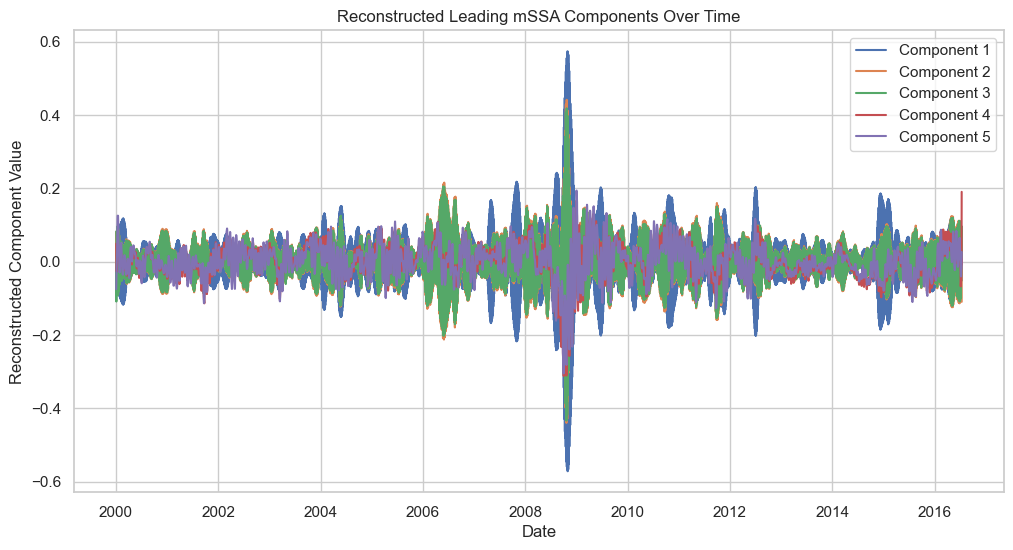

In [14]:
# Create representative factor series by averaging across commodities
factor_df = pd.DataFrame({
    f"Component {component}": reconstructed_df.mean(axis=1)
    for component, reconstructed_df in reconstructed_components.items()
})

display(factor_df.head())

# Plot reconstructed leading component factors
plt.figure(figsize=(12, 6))

for col in factor_df.columns:
    plt.plot(factor_df.index, factor_df[col], label=col)

plt.title("Reconstructed Leading mSSA Components Over Time")
plt.xlabel("Date")
plt.ylabel("Reconstructed Component Value")
plt.legend()
plt.grid(True)
plt.show()

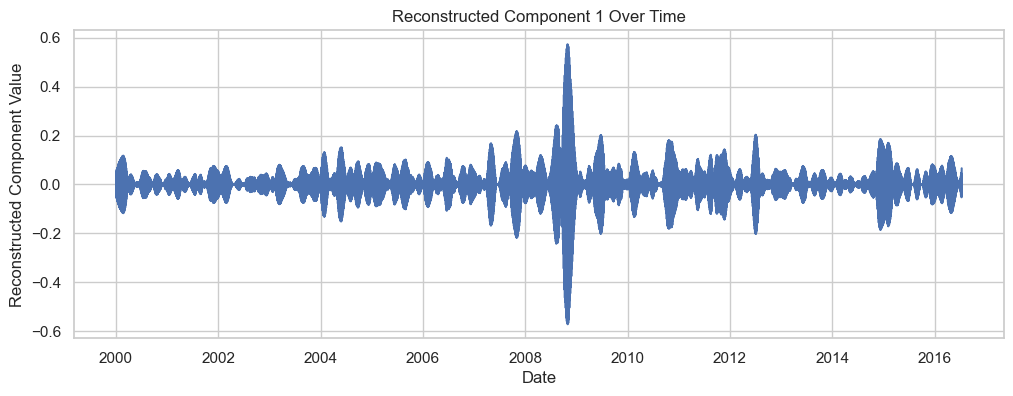

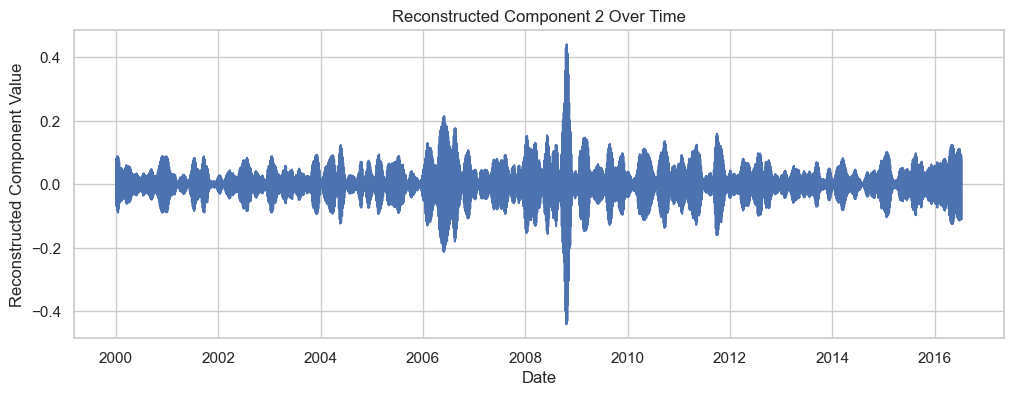

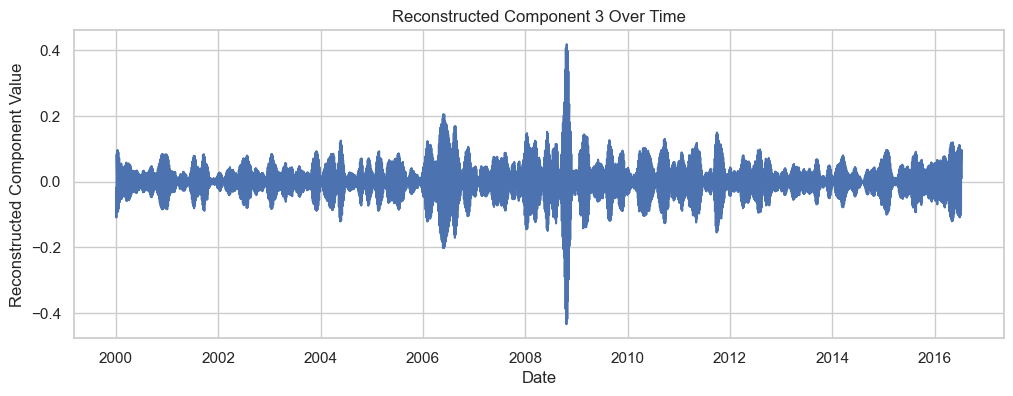

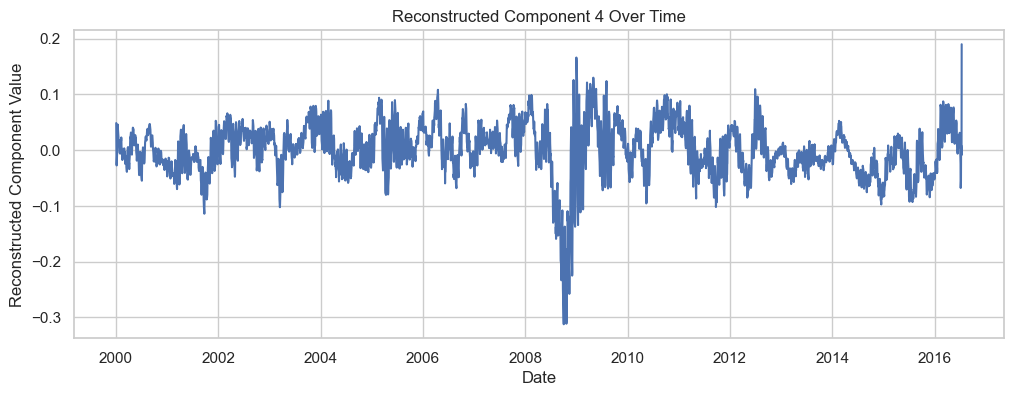

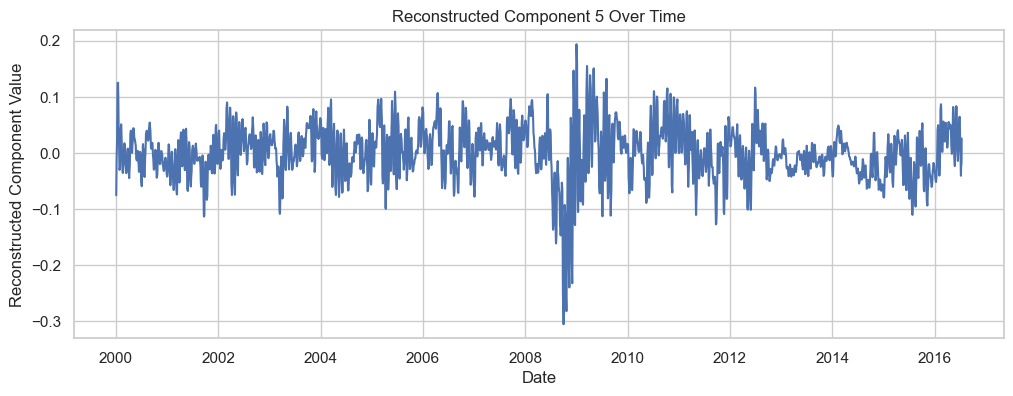

In [15]:
# Optional: plot each leading component separately for readability
for col in factor_df.columns:
    plt.figure(figsize=(12, 4))
    plt.plot(factor_df.index, factor_df[col])
    plt.title(f"Reconstructed {col} Over Time")
    plt.xlabel("Date")
    plt.ylabel("Reconstructed Component Value")
    plt.grid(True)
    plt.show()

## Monthly-Frequency Robustness Check

Because daily commodity returns can be highly noisy, we repeat the mSSA analysis using monthly returns to evaluate whether shared latent commodity factors become more apparent at lower frequency.

In [16]:
# Resample daily returns to monthly returns
# Uses compounded monthly log returns
monthly_returns = returns_df.resample("ME").sum()

print("Monthly returns shape:", monthly_returns.shape)

display(monthly_returns.head())

Monthly returns shape: (284, 22)


,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,LIVE CATTLE,SOYBEAN OIL,ALUMINIUM,SOYBEAN MEAL,ZINC,ULS DIESEL,NICKEL,WHEAT,SUGAR,COFFEE,LEAN HOGS,HRW WHEAT,COTTON
Date,,,,,,,,,,,,,,,,,,,,,,
2000-01-31,0.201589,-0.001764,0.078627,0.062769,0.106893,0.091567,0.001767,-0.010849,0.027715,0.006435,0.071236,0.070990,0.095062,-0.096422,0.339713,0.035932,0.034743,-0.118193,-0.047461,0.013750,0.033172,0.124829
2000-02-29,0.036515,0.038106,0.096165,0.078472,-0.013376,-0.022990,-0.076420,-0.051917,0.046727,-0.005718,-0.065424,-0.095713,0.015409,-0.045980,-0.143667,0.113777,-0.036765,-0.153229,-0.106261,0.023080,-0.025906,-0.022017
2000-03-31,0.064516,-0.055201,-0.123303,-0.125780,0.084598,0.093194,0.022614,-0.000594,-0.119959,0.034176,0.164674,-0.029258,0.051844,0.034569,-0.051383,0.036531,0.059910,0.238085,0.037332,0.102602,0.036432,0.026845
2000-04-30,0.064432,-0.013379,-0.044080,-0.036173,-0.035451,-0.053302,-0.018809,-0.016992,0.036105,0.028344,-0.038980,-0.042829,-0.002908,0.046602,-0.068009,-0.013855,-0.079328,0.043124,-0.084472,0.174913,-0.055620,-0.042694
2000-05-31,0.327013,-0.010981,0.119594,0.169755,-0.017242,0.005571,0.030541,0.001008,0.077311,-0.091244,-0.104036,-0.009409,0.028705,-0.033635,0.010873,-0.096706,0.125891,0.203471,-0.024430,-0.115340,0.115731,0.117244


In [17]:
# Chronological train / validation / test split
n_monthly = len(monthly_returns)

train_end_monthly = int(0.70 * n_monthly)
val_end_monthly = int(0.85 * n_monthly)

train_monthly = monthly_returns.iloc[:train_end_monthly]
val_monthly = monthly_returns.iloc[train_end_monthly:val_end_monthly]
test_monthly = monthly_returns.iloc[val_end_monthly:]

print("Train shape:", train_monthly.shape)
print("Validation shape:", val_monthly.shape)
print("Test shape:", test_monthly.shape)

Train shape: (198, 22)
Validation shape: (43, 22)
Test shape: (43, 22)


In [18]:
# Standardize using training statistics
monthly_mean = train_monthly.mean()
monthly_std = train_monthly.std()

train_monthly_scaled = (train_monthly - monthly_mean) / monthly_std
val_monthly_scaled = (val_monthly - monthly_mean) / monthly_std
test_monthly_scaled = (test_monthly - monthly_mean) / monthly_std

In [19]:
# Select mSSA panel
monthly_panel = train_monthly_scaled.copy()

monthly_panel = (
    monthly_panel
    .replace([np.inf, -np.inf], np.nan)
    .dropna(axis=1)
)

print("Monthly panel shape:", monthly_panel.shape)

Monthly panel shape: (198, 22)


In [20]:
# Choose monthly embedding window length
# Roughly one year of monthly history
L_monthly = 12

n_obs_monthly, n_series_monthly = monthly_panel.shape
K_monthly = n_obs_monthly - L_monthly + 1

print("Window length:", L_monthly)
print("Lagged windows:", K_monthly)

Window length: 12
Lagged windows: 187


In [21]:
# Build monthly trajectory matrix
X_traj_monthly = build_trajectory_matrix(
    monthly_panel,
    L_monthly
)

print("Monthly trajectory matrix shape:", X_traj_monthly.shape)

Monthly trajectory matrix shape: (264, 187)


In [22]:
# Run SVD
U_monthly, singular_values_monthly, Vt_monthly = svd(
    X_traj_monthly,
    full_matrices=False
)

In [23]:
# Variance explained
eigenvalues_monthly = singular_values_monthly ** 2

variance_explained_monthly = (
    eigenvalues_monthly / eigenvalues_monthly.sum()
)

cumulative_variance_monthly = np.cumsum(
    variance_explained_monthly
)

variance_monthly_df = pd.DataFrame({
    "component": np.arange(1, len(singular_values_monthly) + 1),
    "variance_explained": variance_explained_monthly,
    "cumulative_variance_explained": cumulative_variance_monthly
})

display(variance_monthly_df.head(15))

,component,variance_explained,cumulative_variance_explained
0,1,0.050459,0.050459
1,2,0.047719,0.098179
2,3,0.033799,0.131978
3,4,0.032949,0.164927
4,5,0.028568,0.193495
5,6,0.027347,0.220841
6,7,0.025205,0.246046
7,8,0.024430,0.270476
8,9,0.024086,0.294561
9,10,0.023045,0.317606


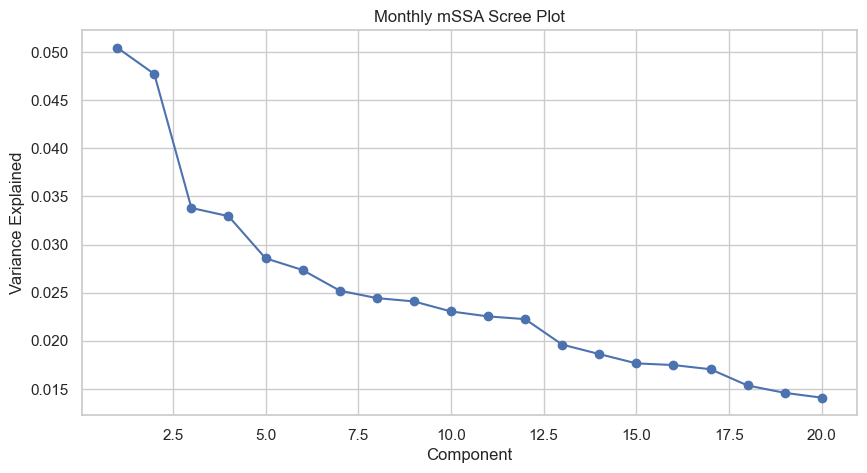

In [24]:
# Scree plot
n_components_plot = min(20, len(variance_monthly_df))

plt.figure(figsize=(10, 5))

plt.plot(
    variance_monthly_df["component"].iloc[:n_components_plot],
    variance_monthly_df["variance_explained"].iloc[:n_components_plot],
    marker="o"
)

plt.title("Monthly mSSA Scree Plot")
plt.xlabel("Component")
plt.ylabel("Variance Explained")

plt.grid(True)
plt.show()

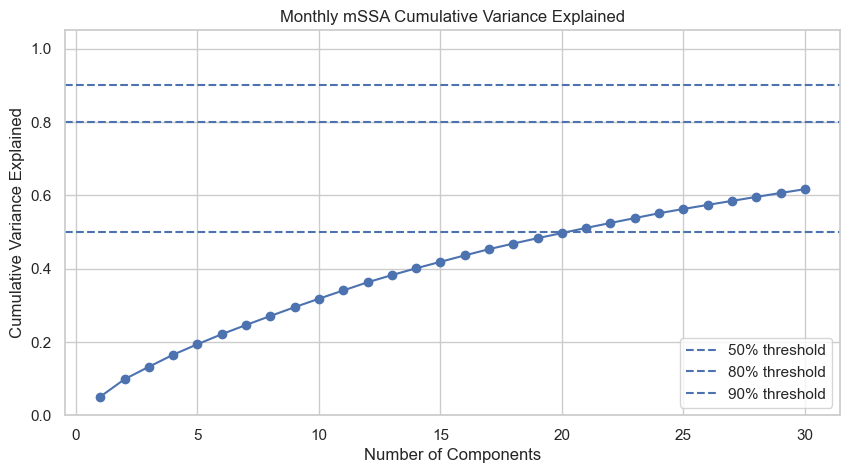

Components needed to explain 50% of variance: 21
Components needed to explain 80% of variance: 56
Components needed to explain 90% of variance: 81


In [26]:
# Plot cumulative variance explained for monthly mSSA
n_components_plot = min(30, len(variance_monthly_df))

plt.figure(figsize=(10, 5))

plt.plot(
    variance_monthly_df["component"].iloc[:n_components_plot],
    variance_monthly_df["cumulative_variance_explained"].iloc[:n_components_plot],
    marker="o"
)

plt.axhline(0.50, linestyle="--", label="50% threshold")
plt.axhline(0.80, linestyle="--", label="80% threshold")
plt.axhline(0.90, linestyle="--", label="90% threshold")

plt.title("Monthly mSSA Cumulative Variance Explained")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

# Components needed to reach common thresholds
for threshold in [0.50, 0.80, 0.90]:
    n_needed = np.argmax(cumulative_variance_monthly >= threshold) + 1
    print(f"Components needed to explain {int(threshold * 100)}% of variance: {n_needed}")

## Extract Leading Monthly Components

We select the first few monthly mSSA components for interpretation. These components represent the strongest shared latent patterns after reducing high-frequency noise through monthly aggregation.

In [27]:
# Number of leading monthly components to interpret
n_leading_monthly = 5

leading_monthly_components = list(range(n_leading_monthly))

print("Leading monthly components selected:", [i + 1 for i in leading_monthly_components])

display(
    variance_monthly_df.loc[leading_monthly_components, [
        "component",
        "variance_explained",
        "cumulative_variance_explained"
    ]]
)

Leading monthly components selected: [1, 2, 3, 4, 5]


,component,variance_explained,cumulative_variance_explained
0,1,0.050459,0.050459
1,2,0.047719,0.098179
2,3,0.033799,0.131978
3,4,0.032949,0.164927
4,5,0.028568,0.193495


## Reconstruct Leading Monthly Components Over Time

We reconstruct each selected monthly mSSA component back into time-series form using diagonal averaging. This allows us to visualize when each latent commodity factor is most active.

In [28]:
# Reconstruct selected monthly components
reconstructed_monthly_components = {}

for component_idx in leading_monthly_components:
    reconstructed_monthly_components[component_idx + 1] = reconstruct_mssa_component(
        component_idx=component_idx,
        U=U_monthly,
        singular_values=singular_values_monthly,
        Vt=Vt_monthly,
        window_length=L_monthly,
        n_series=n_series_monthly,
        columns=list(monthly_panel.columns),
        index=monthly_panel.index
    )

print("Reconstructed monthly components:")
print(list(reconstructed_monthly_components.keys()))

# Preview reconstructed commodity-level series for monthly component 1
display(reconstructed_monthly_components[1].head())

Reconstructed monthly components:
[1, 2, 3, 4, 5]


,NATURAL GAS,GOLD,WTI CRUDE,BRENT CRUDE,SOYBEANS,CORN,COPPER,SILVER,LOW SULPHUR GAS OIL,LIVE CATTLE,SOYBEAN OIL,ALUMINIUM,SOYBEAN MEAL,ZINC,ULS DIESEL,NICKEL,WHEAT,SUGAR,COFFEE,LEAN HOGS,HRW WHEAT,COTTON
Date,,,,,,,,,,,,,,,,,,,,,,
2000-01-31,0.050462,0.074196,0.059549,0.065036,0.107189,0.125647,0.097394,0.100163,0.058899,0.018008,0.119685,0.093923,0.073809,0.075314,0.058484,0.066267,0.083826,0.075801,0.076334,0.002128,0.102767,0.093723
2000-02-29,0.055555,0.071351,0.083755,0.090596,0.114637,0.133886,0.113678,0.106790,0.085368,0.022317,0.129107,0.110981,0.078125,0.081980,0.076401,0.078036,0.083054,0.076140,0.076817,0.016531,0.104283,0.098040
2000-03-31,0.073080,0.087082,0.124016,0.133085,0.143907,0.169983,0.153078,0.135352,0.124483,0.036187,0.166971,0.150922,0.096032,0.105811,0.111827,0.101928,0.097866,0.094005,0.098197,0.027276,0.125619,0.128737
2000-04-30,0.086751,0.085237,0.156650,0.165590,0.153949,0.183091,0.178166,0.143603,0.157944,0.041960,0.181979,0.181078,0.100558,0.116619,0.138728,0.117099,0.093390,0.094991,0.104830,0.045518,0.125052,0.136220
2000-05-31,0.089463,0.066937,0.174968,0.182740,0.138401,0.167374,0.179580,0.127965,0.176073,0.048641,0.169011,0.187231,0.089000,0.107000,0.154089,0.113477,0.069833,0.078997,0.094461,0.059335,0.099805,0.123829


## Plot Reconstructed Monthly Components

We average the reconstructed commodity-level series within each component to create one representative latent factor time series per component.

,Component 1,Component 2,Component 3,Component 4,Component 5
Date,,,,,
2000-01-31,0.076300,-0.002454,0.182703,-0.001207,0.025893
2000-02-29,0.085792,0.002260,-0.101654,-0.093151,0.030633
2000-03-31,0.112975,0.008204,0.006534,-0.095163,-0.094693
2000-04-30,0.126773,0.010561,-0.016697,-0.009053,0.012812
2000-05-31,0.122646,0.007795,0.020629,0.025078,0.102508


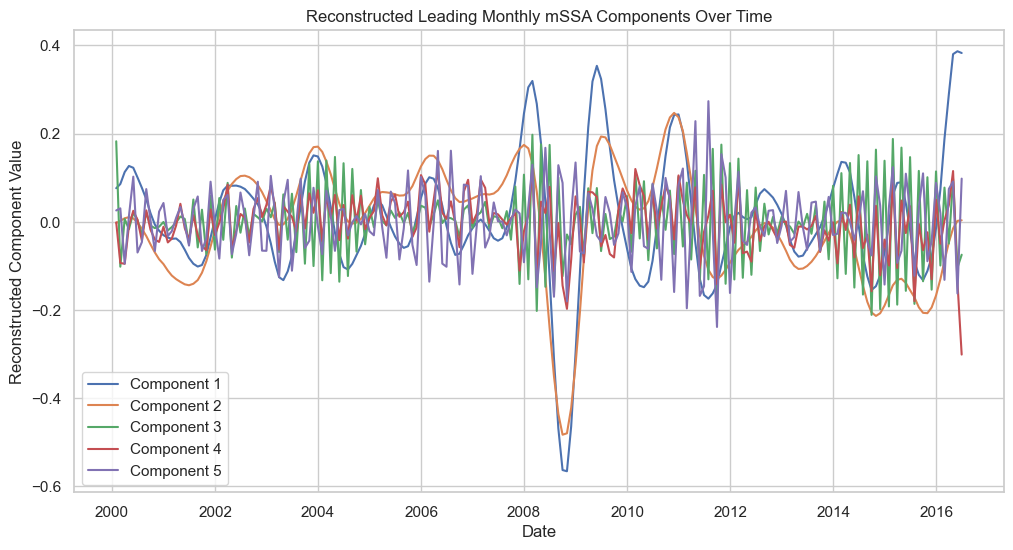

In [29]:
# Create representative monthly factor series by averaging across commodities
monthly_factor_df = pd.DataFrame({
    f"Component {component}": reconstructed_df.mean(axis=1)
    for component, reconstructed_df in reconstructed_monthly_components.items()
})

display(monthly_factor_df.head())

# Plot reconstructed leading monthly components together
plt.figure(figsize=(12, 6))

for col in monthly_factor_df.columns:
    plt.plot(monthly_factor_df.index, monthly_factor_df[col], label=col)

plt.title("Reconstructed Leading Monthly mSSA Components Over Time")
plt.xlabel("Date")
plt.ylabel("Reconstructed Component Value")
plt.legend()
plt.grid(True)
plt.show()

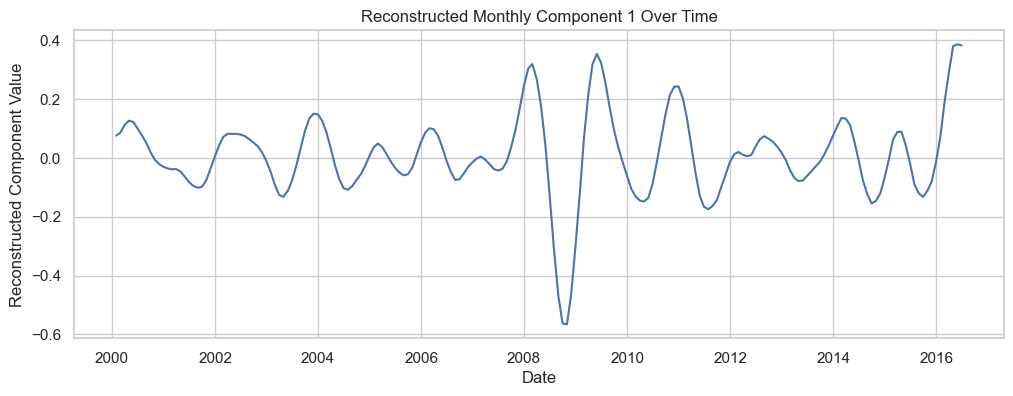

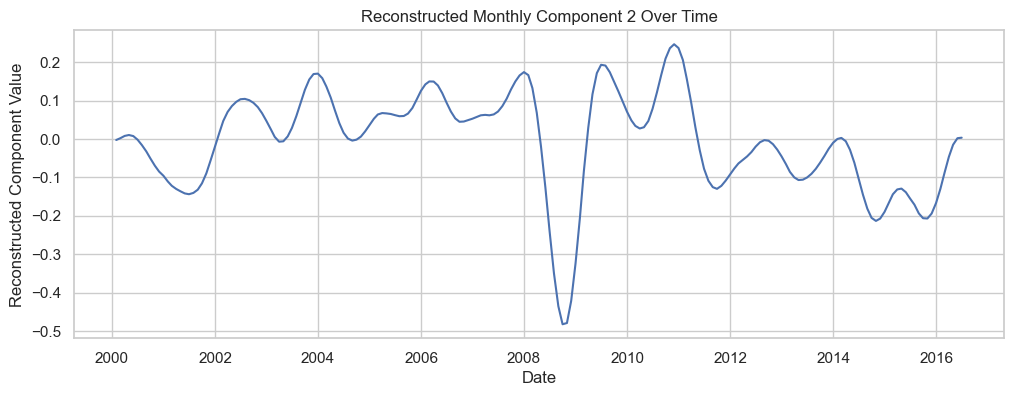

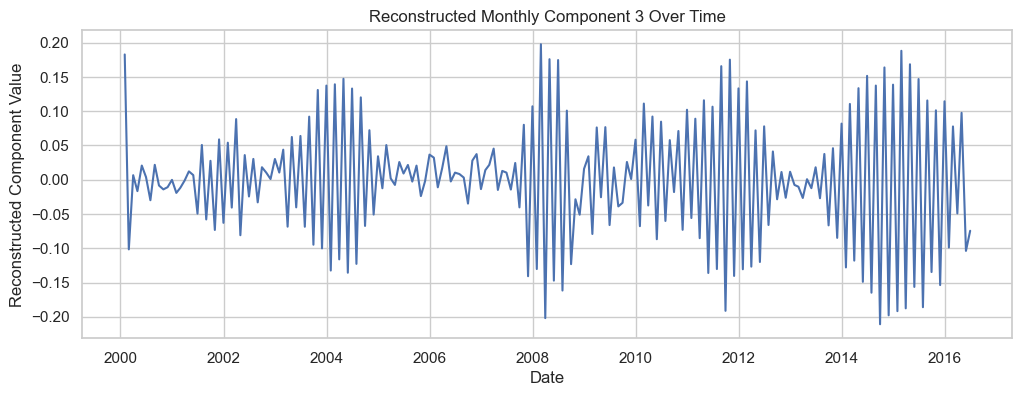

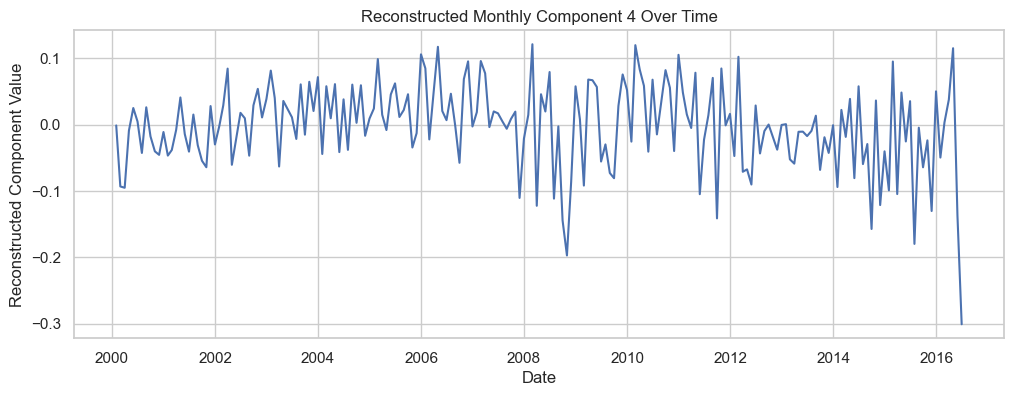

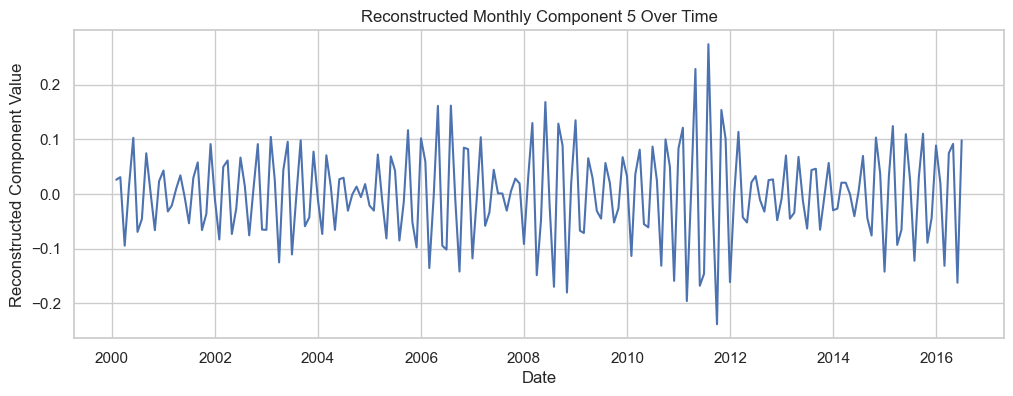

In [30]:
# Plot each reconstructed monthly component separately
for col in monthly_factor_df.columns:
    plt.figure(figsize=(12, 4))
    plt.plot(monthly_factor_df.index, monthly_factor_df[col])
    plt.title(f"Reconstructed Monthly {col} Over Time")
    plt.xlabel("Date")
    plt.ylabel("Reconstructed Component Value")
    plt.grid(True)
    plt.show()

## Calculate Commodity Loadings / Contributions

To interpret which commodities drive each latent factor, we estimate commodity contributions from the left singular vectors. For each component, we sum the squared weights across the lag window for each commodity, then normalize contributions so they sum to 1.

In [31]:
def calculate_mssa_contributions(U_matrix: np.ndarray, component_indices: list,
                                 window_length: int, columns: list) -> pd.DataFrame:
    """
    Estimate commodity contributions to selected mSSA components.

    For each component, contribution is calculated by summing squared
    left-singular-vector weights across the lag window for each commodity.
    """
    contribution_dict = {}

    for component_idx in component_indices:
        u_component = U_matrix[:, component_idx]

        commodity_contributions = {}

        for j, col in enumerate(columns):
            row_start = j * window_length
            row_end = (j + 1) * window_length

            commodity_weight = np.sum(u_component[row_start:row_end] ** 2)
            commodity_contributions[col] = commodity_weight

        contribution_series = pd.Series(commodity_contributions)
        contribution_series = contribution_series / contribution_series.sum()

        contribution_dict[f"Component {component_idx + 1}"] = contribution_series

    contributions_df = pd.DataFrame(contribution_dict)

    return contributions_df


monthly_contributions_df = calculate_mssa_contributions(
    U_matrix=U_monthly,
    component_indices=leading_monthly_components,
    window_length=L_monthly,
    columns=list(monthly_panel.columns)
)

display(monthly_contributions_df.round(3))

,Component 1,Component 2,Component 3,Component 4,Component 5
NATURAL GAS,0.017,0.022,0.007,0.012,0.039
GOLD,0.013,0.023,0.015,0.036,0.063
WTI CRUDE,0.098,0.083,0.043,0.069,0.035
BRENT CRUDE,0.099,0.087,0.052,0.077,0.038
SOYBEANS,0.049,0.038,0.136,0.076,0.056
CORN,0.043,0.035,0.091,0.058,0.052
COPPER,0.098,0.095,0.039,0.061,0.043
SILVER,0.039,0.046,0.016,0.039,0.065
LOW SULPHUR GAS OIL,0.089,0.085,0.049,0.066,0.038
LIVE CATTLE,0.004,0.007,0.027,0.014,0.015


## Plot Commodity Loadings / Contributions

The heatmap shows which commodities contribute most strongly to each leading monthly mSSA component. Darker cells indicate stronger participation in that latent factor.

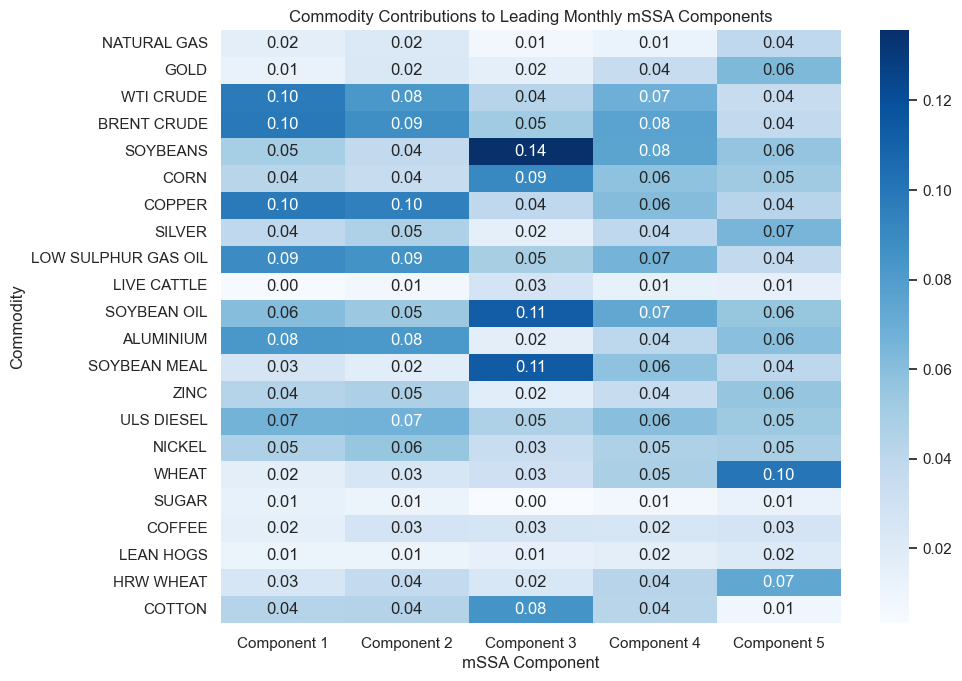

In [32]:
# Heatmap of commodity contributions
plt.figure(figsize=(10, max(6, 0.35 * len(monthly_contributions_df))))

sns.heatmap(
    monthly_contributions_df,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Commodity Contributions to Leading Monthly mSSA Components")
plt.xlabel("mSSA Component")
plt.ylabel("Commodity")
plt.show()

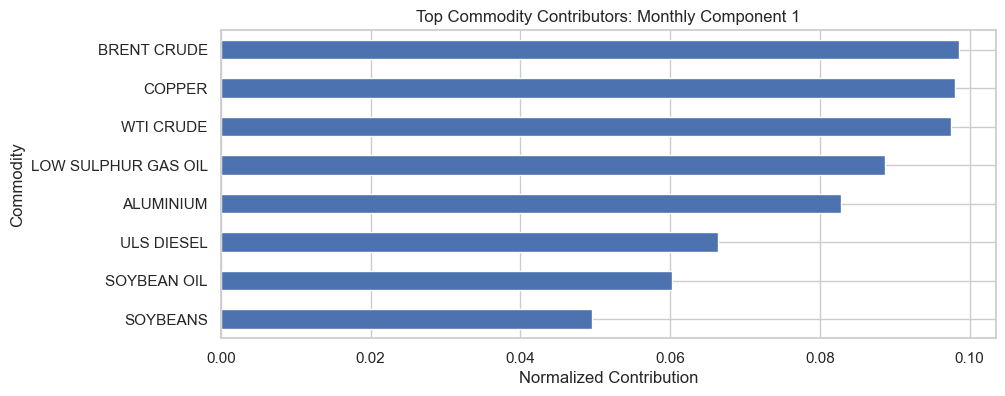

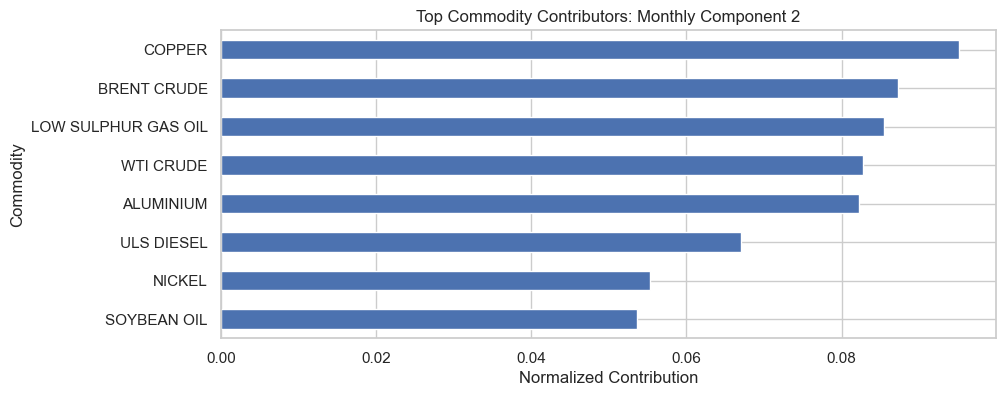

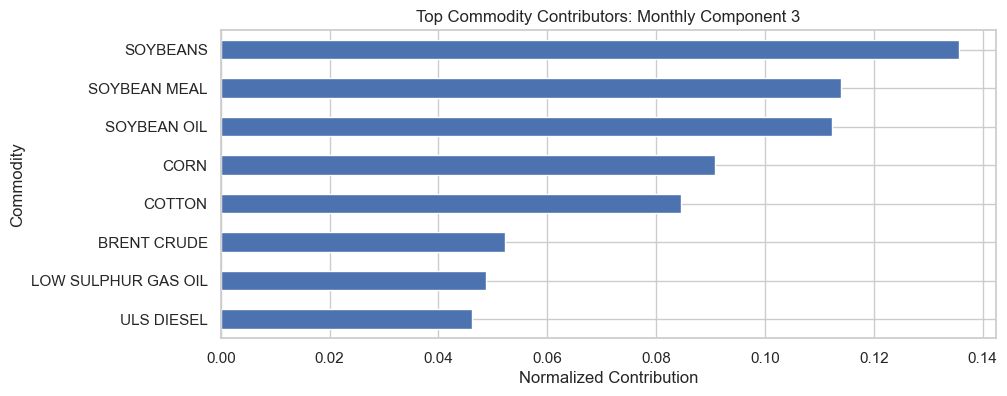

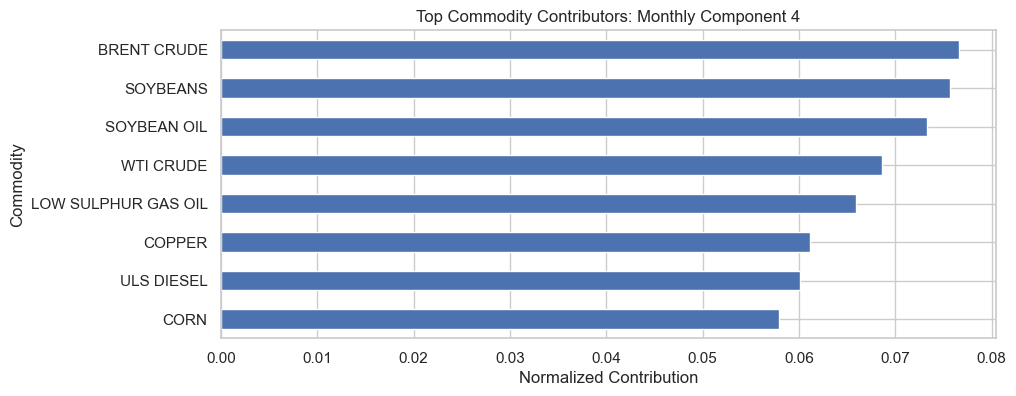

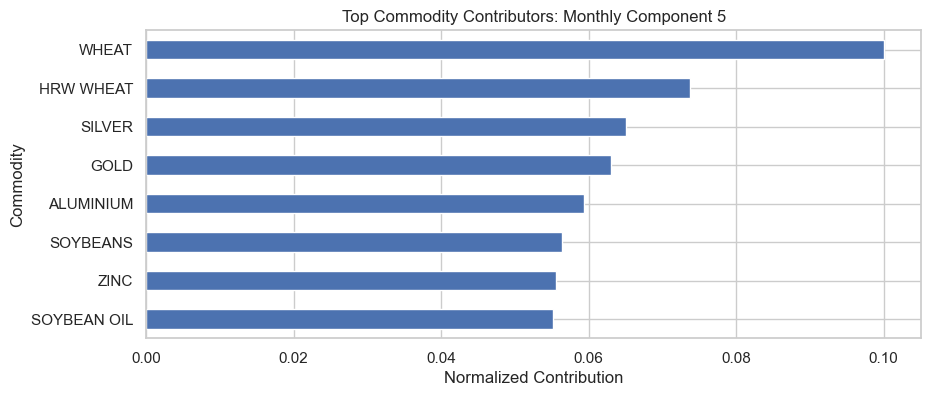

In [33]:
# Bar plots of top contributing commodities for each component
top_n = 8

for component in monthly_contributions_df.columns:
    top_contributors = monthly_contributions_df[component].sort_values(ascending=False).head(top_n)

    plt.figure(figsize=(10, 4))
    top_contributors.sort_values().plot(kind="barh")

    plt.title(f"Top Commodity Contributors: Monthly {component}")
    plt.xlabel("Normalized Contribution")
    plt.ylabel("Commodity")
    plt.grid(True, axis="x")
    plt.show()